# 🛒 Stage 2: Supermarket Sales EDA Dashboard
### ML Roadmap — Exploratory Data Analysis Project

## Step 0: Install & Import Libraries

In [3]:
# Uncomment to install if needed
# !pip install pandas numpy matplotlib seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

BRAND_COLORS = {
    'A': '#2ecc71',   # Branch A — green
    'B': '#3498db',   # Branch B — blue
    'C': '#e74c3c',   # Branch C — red
    'primary': '#2c3e50',
    'accent': '#f39c12'
}

print('✅ Libraries loaded')
print(f'   Pandas  : {pd.__version__}')
print(f'   Plotly  : {plotly.__version__}')

✅ Libraries loaded
   Pandas  : 3.0.2
   Plotly  : 6.7.0


---
## Step 1: Generate & Load the Dataset

We generate a realistic supermarket sales dataset modeled after the famous [Kaggle Supermarket Sales dataset](https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales) — 1,000 transactions across 3 branches, Jan–Mar 2019.

In [4]:
def generate_supermarket_data(n=1000, seed=42):
    """
    Generate a realistic supermarket sales dataset.
    Mirrors structure of the Kaggle Supermarket Sales dataset.
    """
    np.random.seed(seed)

    branches      = ['A - Yangon', 'B - Mandalay', 'C - Naypyitaw']
    product_lines = [
        'Health and beauty', 'Electronic accessories',
        'Home and lifestyle', 'Sports and travel',
        'Food and beverages', 'Fashion accessories'
    ]
    payment_methods = ['Ewallet', 'Cash', 'Credit card']
    customer_types  = ['Member', 'Normal']
    genders         = ['Male', 'Female']

    # Timestamps spread over Q1 2019
    dates        = pd.date_range('2019-01-01', '2019-03-30', freq='h')
    invoice_dates = sorted(np.random.choice(dates, n))

    branch       = np.random.choice(branches, n, p=[0.34, 0.33, 0.33])
    product_line = np.random.choice(product_lines, n)
    customer_type = np.random.choice(customer_types, n, p=[0.52, 0.48])
    gender       = np.random.choice(genders, n)
    payment      = np.random.choice(payment_methods, n, p=[0.35, 0.34, 0.31])

    unit_price = np.round(np.random.uniform(10, 99, n), 2)
    quantity   = np.random.randint(1, 11, n)

    # Product line pricing modifier (domain knowledge)
    price_mods = {
        'Health and beauty': 1.10,
        'Electronic accessories': 1.20,
        'Food and beverages': 0.85,
        'Home and lifestyle': 1.0,
        'Sports and travel': 1.05,
        'Fashion accessories': 0.95
    }
    for i, pl in enumerate(product_line):
        unit_price[i] = round(unit_price[i] * price_mods[pl], 2)

    subtotal     = unit_price * quantity
    tax          = np.round(subtotal * 0.05, 4)
    total        = np.round(subtotal + tax, 4)
    rating       = np.round(np.clip(np.random.normal(7.0, 1.5, n), 4, 10), 1)

    df = pd.DataFrame({
        'Invoice ID'             : [f'{np.random.randint(100,999)}-{np.random.randint(10,99)}-{np.random.randint(1000,9999)}' for _ in range(n)],
        'Branch'                 : [b.split(' - ')[0] for b in branch],
        'City'                   : [b.split(' - ')[1] for b in branch],
        'Customer type'          : customer_type,
        'Gender'                 : gender,
        'Product line'           : product_line,
        'Unit price'             : unit_price,
        'Quantity'               : quantity,
        'Tax 5%'                 : tax,
        'Total'                  : total,
        'Date'                   : [pd.Timestamp(d).date() for d in invoice_dates],
        'Time'                   : [pd.Timestamp(d).strftime('%H:%M') for d in invoice_dates],
        'Payment'                : payment,
        'cogs'                   : subtotal,
        'gross margin percentage': np.full(n, 4.761904762),
        'gross income'           : tax,
        'Rating'                 : rating
    })
    return df


# Generate and load
df = generate_supermarket_data(n=1000)
df.to_csv('supermarket_sales.csv', index=False)

# ── OR load from the provided CSV ────────────────────────────────────────────
# df = pd.read_csv('supermarket_sales.csv')

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 1,000 rows × 17 columns


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,365-93-8991,A,Yangon,Member,Male,Food and beverages,77.05,10,38.52,809.02,2019-01-01,01:00,Ewallet,770.50,4.76,38.52,9.00
1,179-46-9592,A,Yangon,Member,Male,Home and lifestyle,76.17,2,7.62,159.96,2019-01-01,03:00,Ewallet,152.34,4.76,7.62,8.50
2,915-93-3329,B,Mandalay,Normal,Male,Food and beverages,48.81,4,9.76,205.00,2019-01-01,04:00,Cash,195.24,4.76,9.76,4.90
3,211-92-8545,A,Yangon,Member,Male,Home and lifestyle,86.60,4,17.32,363.72,2019-01-01,05:00,Ewallet,346.40,4.76,17.32,8.60
4,850-21-1569,B,Mandalay,Member,Female,Electronic accessories,86.22,4,17.24,362.12,2019-01-01,09:00,Cash,344.88,4.76,17.24,6.80


---
## Step 2: Data Overview & Quality Check

In [5]:
print('━'*55)
print('           DATASET OVERVIEW')
print('━'*55)
print(f'  Rows            : {df.shape[0]:,}')
print(f'  Columns         : {df.shape[1]}')
print(f'  Memory usage    : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print(f'  Date range      : {df["Date"].min()}  →  {df["Date"].max()}')
print(f'  Total revenue   : ₹{df["Total"].sum():,.2f}')
print(f'  Avg basket size : ₹{df["Total"].mean():,.2f}')
print()

print('📋 Dtypes & Missing Values:')
summary = pd.DataFrame({
    'dtype'   : df.dtypes,
    'missing' : df.isnull().sum(),
    'unique'  : df.nunique()
})
print(summary.to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
           DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Rows            : 1,000
  Columns         : 17
  Memory usage    : 540.5 KB
  Date range      : 2019-01-01  →  2019-03-29
  Total revenue   : ₹316,271.86
  Avg basket size : ₹316.27

📋 Dtypes & Missing Values:
                           dtype  missing  unique
Invoice ID                   str        0    1000
Branch                       str        0       3
City                         str        0       3
Customer type                str        0       2
Gender                       str        0       2
Product line                 str        0       6
Unit price               float64        0     955
Quantity                   int32        0      10
Tax 5%                   float64        0     990
Total                    float64        0     990
Date                      object        0      88
Time                         str        0      2

## 2.1 Date & Time Feature Engineering

In [6]:
# ── Parse date & engineer time features ──────────────────────────────────────
df['Date']     = pd.to_datetime(df['Date'])
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])
df['Month']    = df['Date'].dt.month_name()
df['Month_No'] = df['Date'].dt.month
df['DayOfWeek']= df['Date'].dt.day_name()
df['Hour']     = df['DateTime'].dt.hour
df['Week']     = df['Date'].dt.isocalendar().week.astype(int)

# Order month & day correctly for plotting
month_order   = ['January', 'February', 'March']
day_order     = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Month']   = pd.Categorical(df['Month'],   categories=month_order,   ordered=True)
df['DayOfWeek']= pd.Categorical(df['DayOfWeek'], categories=day_order, ordered=True)

print('✅ Time features engineered:')
print('   Month, Month_No, DayOfWeek, Hour, Week, DateTime')
df[['Date','Time','Month', 'Month_No','DayOfWeek','Hour', 'Week', 'DateTime']].head(4)

✅ Time features engineered:
   Month, Month_No, DayOfWeek, Hour, Week, DateTime


,Date,Time,Month,Month_No,DayOfWeek,Hour,Week,DateTime
0,2019-01-01,01:00,January,1,Tuesday,1,1,2019-01-01 01:00:00
1,2019-01-01,03:00,January,1,Tuesday,3,1,2019-01-01 03:00:00
2,2019-01-01,04:00,January,1,Tuesday,4,1,2019-01-01 04:00:00
3,2019-01-01,05:00,January,1,Tuesday,5,1,2019-01-01 05:00:00


---
## Step 3: Univariate Analysis


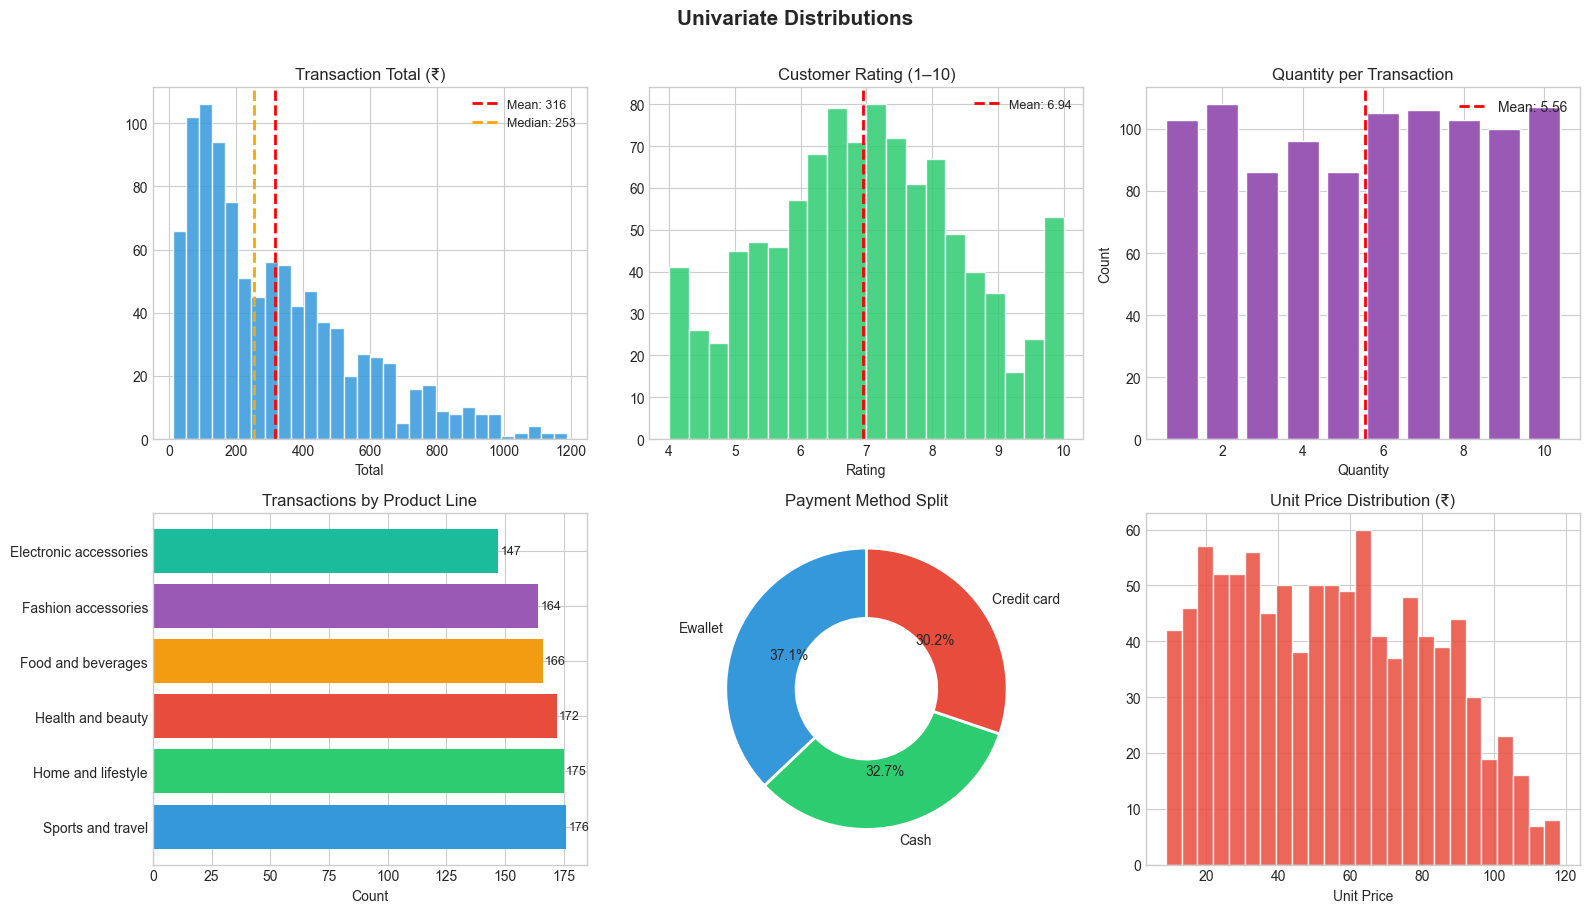

💾 Saved: eda_01_univariate.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Univariate Distributions', fontsize=15, fontweight='bold', y=1.01)

# 1. Total revenue distribution
axes[0,0].hist(df['Total'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['Total'].mean(), color='red', linestyle='--', lw=2,
                  label=f'Mean: {df["Total"].mean():.0f}')
axes[0,0].axvline(df['Total'].median(), color='orange', linestyle='--', lw=2,
                  label=f'Median: {df["Total"].median():.0f}')
axes[0,0].set_title('Transaction Total (₹)')
axes[0,0].set_xlabel('Total')
axes[0,0].legend(fontsize=9)

# 2. Rating distribution
axes[0,1].hist(df['Rating'], bins=20, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0,1].axvline(df['Rating'].mean(), color='red', linestyle='--', lw=2,
                  label=f'Mean: {df["Rating"].mean():.2f}')
axes[0,1].set_title('Customer Rating (1–10)')
axes[0,1].set_xlabel('Rating')
axes[0,1].legend(fontsize=9)

# 3. Quantity distribution
qty_counts = df['Quantity'].value_counts().sort_index()
axes[0,2].bar(qty_counts.index, qty_counts.values, color='#9b59b6', edgecolor='white')
mean_qty = df['Quantity'].mean()
axes[0,2].axvline(mean_qty, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_qty:.2f}')
axes[0,2].legend()
axes[0,2].set_title('Quantity per Transaction')
axes[0,2].set_xlabel('Quantity')
axes[0,2].set_ylabel('Count')


# 4. Product line distribution
pl_counts = df['Product line'].value_counts()
colors_pl = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c']
axes[1,0].barh(pl_counts.index, pl_counts.values, color=colors_pl)
axes[1,0].set_title('Transactions by Product Line')
axes[1,0].set_xlabel('Count')
for i, v in enumerate(pl_counts.values):
    axes[1,0].text(v+1, i, str(v), va='center', fontsize=9)

# 5. Payment method
pay_counts = df['Payment'].value_counts()
wedge_props = dict(width=0.5, edgecolor='white', linewidth=2)
axes[1,1].pie(pay_counts.values, labels=pay_counts.index, autopct='%1.1f%%',
              colors=['#3498db','#2ecc71','#e74c3c'], wedgeprops=wedge_props,
              startangle=90)
axes[1,1].set_title('Payment Method Split')

# 6. Unit price distribution
axes[1,2].hist(df['Unit price'], bins=25, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1,2].set_title('Unit Price Distribution (₹)')
axes[1,2].set_xlabel('Unit Price')

plt.tight_layout()
plt.savefig('eda_01_univariate.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_01_univariate.png')

---
## Step 4: Branch & City Analysis

In [8]:
# Branch-level summary table
branch_summary = df.groupby('Branch').agg(
    Transactions=('Invoice ID', 'count'),
    Total_Revenue=('Total', 'sum'),
    Avg_Transaction=('Total', 'mean'),
    Avg_Rating=('Rating', 'mean'),
    Avg_Quantity=('Quantity', 'mean'),
    Total_Items=('Quantity', 'sum')
).round(2)

branch_summary['Revenue_Share_%'] = (branch_summary['Total_Revenue'] /
                                      branch_summary['Total_Revenue'].sum() * 100).round(1)
print('📊 Branch Performance Summary:')
print(branch_summary.to_string())

📊 Branch Performance Summary:
        Transactions  Total_Revenue  Avg_Transaction  Avg_Rating  Avg_Quantity  Total_Items  Revenue_Share_%
Branch                                                                                                      
A                332      105730.77           318.47        6.91          5.54         1839            33.40
B                326       99980.23           306.69        6.92          5.48         1785            31.60
C                342      110560.86           323.28        7.00          5.65         1933            35.00


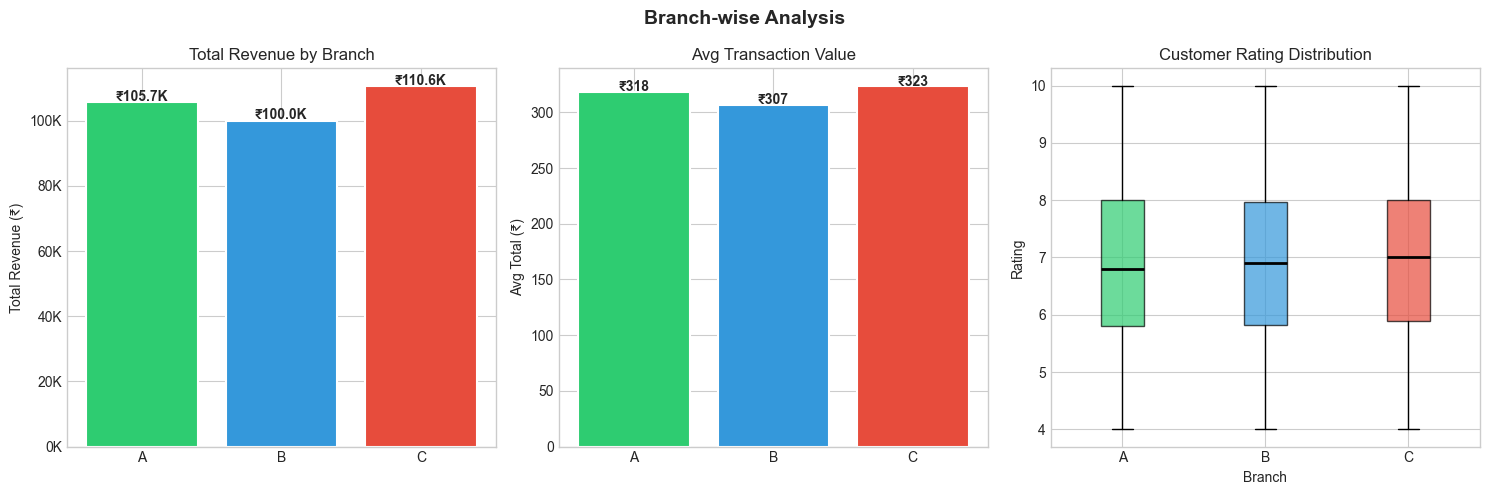

💾 Saved: eda_02_branch.png

📊 Box Plot Statistical Summary
Branch  Minimum   Q1  Median   Q3  Maximum  IQR  Outlier_Count
     A     4.00 5.80    6.80 8.00    10.00 2.20              0
     B     4.00 5.82    6.90 7.98    10.00 2.15              0
     C     4.00 5.90    7.00 8.00    10.00 2.10              0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Branch-wise Analysis', fontsize=14, fontweight='bold')

br_colors = [BRAND_COLORS['A'], BRAND_COLORS['B'], BRAND_COLORS['C']]

# Revenue by branch
rev = branch_summary['Total_Revenue']
bars = axes[0].bar(rev.index, rev.values, color=br_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Total Revenue by Branch')
axes[0].set_ylabel('Total Revenue (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 500, f'₹{h/1000:.1f}K',
                 ha='center', fontweight='bold', fontsize=10)

# Avg transaction by branch
avg_t = branch_summary['Avg_Transaction']
axes[1].bar(avg_t.index, avg_t.values, color=br_colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Avg Transaction Value')
axes[1].set_ylabel('Avg Total (₹)')
for i, v in enumerate(avg_t):
    axes[1].text(i, v + 0.5, f'₹{v:.0f}', ha='center', fontweight='bold', fontsize=10)

# Rating by branch (box plot)
branch_groups = [df[df['Branch'] == b]['Rating'].values for b in ['A','B','C']]
bp = axes[2].boxplot(branch_groups, labels=['A','B','C'], patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], br_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Customer Rating Distribution')
axes[2].set_ylabel('Rating')
axes[2].set_xlabel('Branch')

plt.tight_layout()
plt.savefig('eda_02_branch.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_02_branch.png')

summary_list = []

for branch in ['A', 'B', 'C']:

    ratings = df[df['Branch'] == branch]['Rating']

    q1 = ratings.quantile(0.25)
    median = ratings.median()
    q3 = ratings.quantile(0.75)

    minimum = ratings.min()
    maximum = ratings.max()

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = ratings[(ratings < lower_bound) | (ratings > upper_bound)]

    summary_list.append({
        'Branch': branch,
        'Minimum': minimum,
        'Q1': round(q1, 2),
        'Median': round(median, 2),
        'Q3': round(q3, 2),
        'Maximum': maximum,
        'IQR': round(iqr, 2),
        'Outlier_Count': len(outliers)
    })

# Convert to DataFrame
boxplot_summary = pd.DataFrame(summary_list)

print('\n📊 Box Plot Statistical Summary')
print(boxplot_summary.to_string(index=False))

---
## Step 5: Product Line Analysis

In [22]:
pl_summary = df.groupby('Product line').agg(
    Total_Revenue=('Total', 'sum'),
    Avg_Total=('Total', 'mean'),
    Transactions=('Invoice ID', 'count'),
    Avg_Rating=('Rating', 'mean'),
).round(2).sort_values('Total_Revenue', ascending=False)

print('📦 Product Line Summary:')
print(pl_summary.to_string())

📦 Product Line Summary:
                        Total_Revenue  Avg_Total  Transactions  Avg_Rating
Product line                                                              
Sports and travel            60496.24     343.73           176        7.00
Electronic accessories       58651.50     398.99           147        6.78
Health and beauty            57398.17     333.71           172        7.05
Home and lifestyle           51537.23     294.50           175        6.98
Fashion accessories          46925.50     286.13           164        6.59
Food and beverages           41263.23     248.57           166        7.23


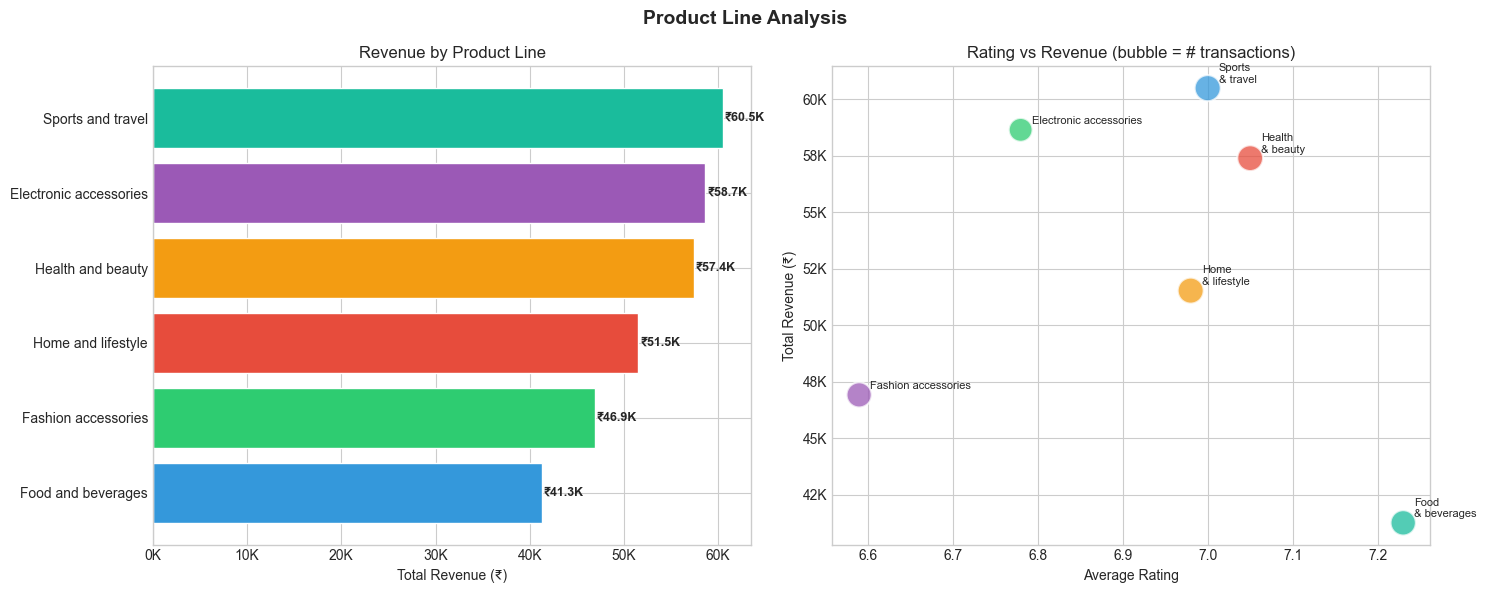

💾 Saved: eda_03_product_line.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Product Line Analysis', fontsize=14, fontweight='bold')

pl_colors = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c']

# Revenue by product line
rev_sorted = pl_summary['Total_Revenue'].sort_values()
axes[0].barh(rev_sorted.index, rev_sorted.values, color=pl_colors, edgecolor='white')
axes[0].set_title('Revenue by Product Line')
axes[0].set_xlabel('Total Revenue (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for i, v in enumerate(rev_sorted.values):
    axes[0].text(v + 200, i, f'₹{v/1000:.1f}K', va='center', fontsize=9, fontweight='bold')

# Rating vs Revenue (bubble chart)
axes[1].scatter(
    pl_summary['Avg_Rating'],
    pl_summary['Total_Revenue'],
    s=pl_summary['Transactions'] * 2,  # bubble size = # transactions
    c=pl_colors, alpha=0.75, edgecolors='white', linewidth=1.5
)
for i, (idx, row) in enumerate(pl_summary.iterrows()):
    axes[1].annotate(idx.replace(' and ', '\n& '),
                     (row['Avg_Rating'], row['Total_Revenue']),
                     textcoords='offset points', xytext=(8, 4), fontsize=8)
axes[1].set_title('Rating vs Revenue (bubble = # transactions)')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Total Revenue (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('eda_03_product_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_03_product_line.png')

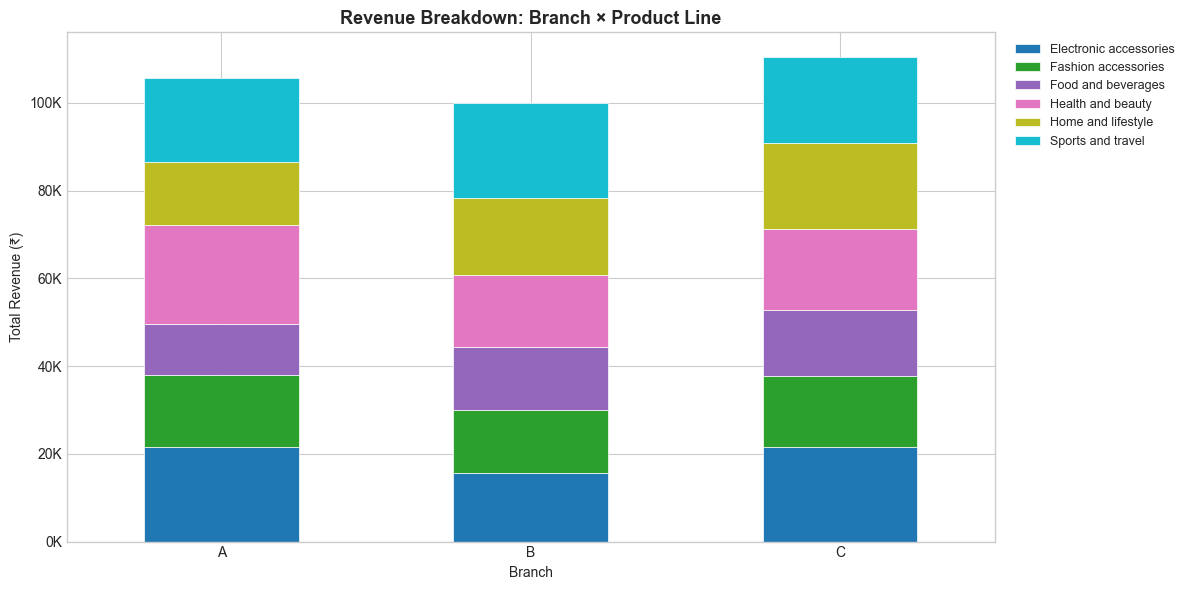

💾 Saved: eda_04_branch_product.png


In [12]:
# Stacked bar: Revenue by Branch × Product Line
cross = df.pivot_table(values='Total', index='Branch', columns='Product line', aggfunc='sum')

ax = cross.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10',
                edgecolor='white', linewidth=0.5)
plt.title('Revenue Breakdown: Branch × Product Line', fontsize=13, fontweight='bold')
plt.xlabel('Branch')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('eda_04_branch_product.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_04_branch_product.png')

---
## Step 6: Time Series Analysis — Sales Trends

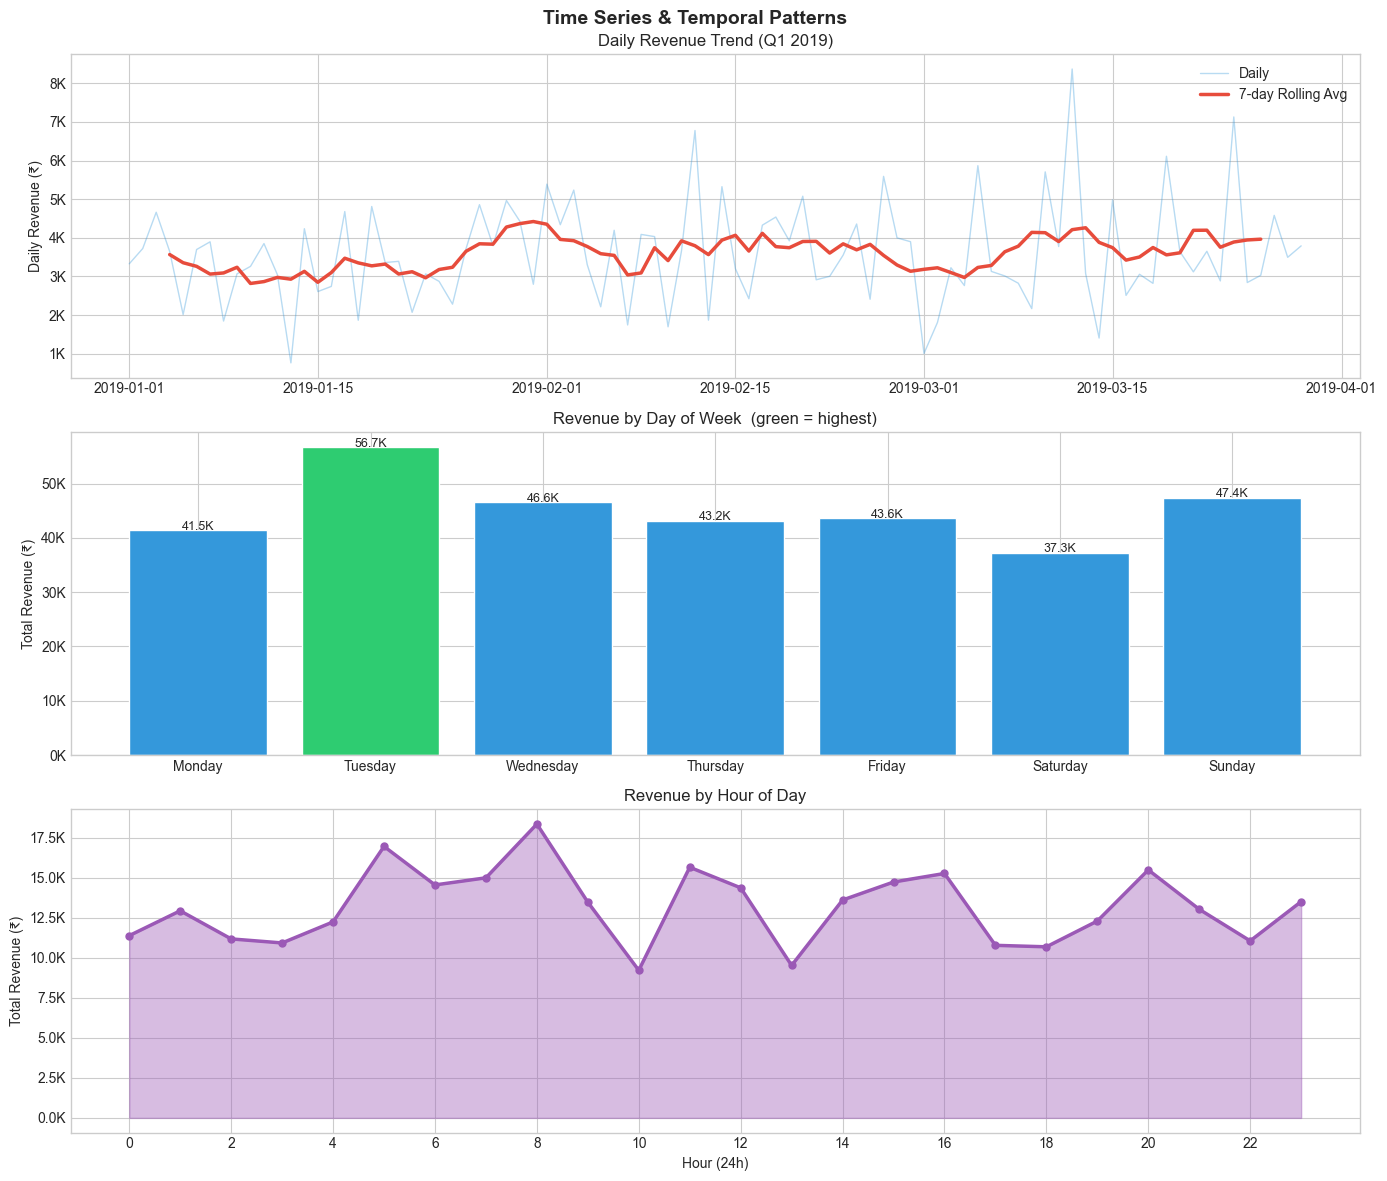

💾 Saved: eda_05_time_series.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Time Series & Temporal Patterns', fontsize=14, fontweight='bold')

# 1. Daily revenue trend with 7-day rolling average
daily = df.groupby('Date')['Total'].sum().reset_index()
daily['Rolling_7'] = daily['Total'].rolling(7, center=True).mean()

# Daily actual revenue.
axes[0].plot(daily['Date'], daily['Total'], alpha=0.35, color='#3498db', linewidth=1, label='Daily')
# இதுதான் main trend.
axes[0].plot(daily['Date'], daily['Rolling_7'], color='#e74c3c', linewidth=2.5, label='7-day Rolling Avg')

axes[0].set_title('Daily Revenue Trend (Q1 2019)')
axes[0].set_ylabel('Daily Revenue (₹)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# 2. Revenue by day of week
dow = df.groupby('DayOfWeek', observed=True)['Total'].sum()
bar_colors = ['#2ecc71' if v == dow.max() else '#3498db' for v in dow.values]
axes[1].bar(dow.index, dow.values, color=bar_colors, edgecolor='white')
axes[1].set_title('Revenue by Day of Week  (green = highest)')
axes[1].set_ylabel('Total Revenue (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for i, v in enumerate(dow.values):
    axes[1].text(i, v + 100, f'{v/1000:.1f}K', ha='center', fontsize=9)

# 3. Revenue by hour of day
hourly = df.groupby('Hour')['Total'].sum()
axes[2].fill_between(hourly.index, hourly.values, color='#9b59b6', alpha=0.4)
axes[2].plot(hourly.index, hourly.values, color='#9b59b6', linewidth=2.5, marker='o', markersize=5)
axes[2].set_title('Revenue by Hour of Day')
axes[2].set_xlabel('Hour (24h)')
axes[2].set_ylabel('Total Revenue (₹)')
axes[2].set_xticks(range(int(hourly.index.min()), int(hourly.index.max())+1, 2))
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}K'))

plt.tight_layout()
plt.savefig('eda_05_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_05_time_series.png')

---
## Step 7: Customer Behaviour Analysis

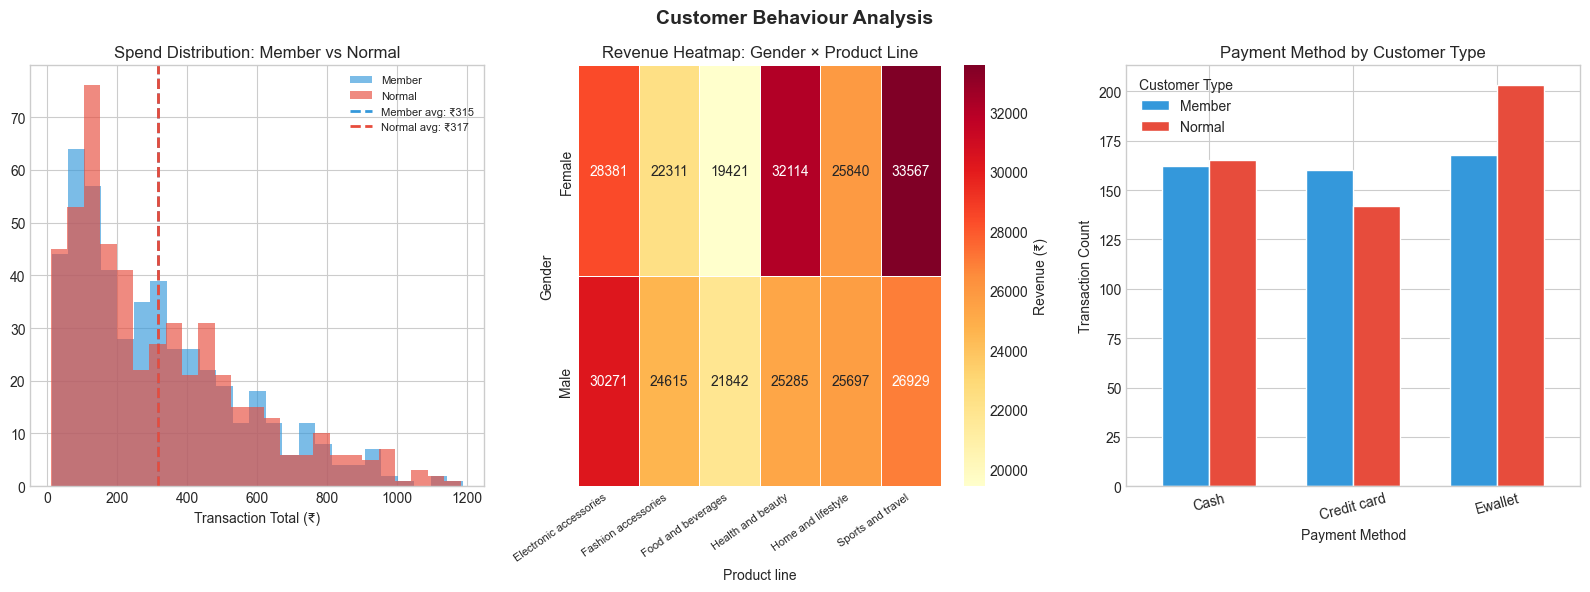

💾 Saved: eda_06_customer.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Customer Behaviour Analysis', fontsize=14, fontweight='bold')

# 1. Member vs Normal — revenue distribution
member_totals = df[df['Customer type'] == 'Member']['Total']
normal_totals = df[df['Customer type'] == 'Normal']['Total']
axes[0].hist(member_totals, bins=25, alpha=0.65, color='#3498db', label='Member')
axes[0].hist(normal_totals, bins=25, alpha=0.65, color='#e74c3c', label='Normal')
axes[0].axvline(member_totals.mean(), color='#3498db', linestyle='--', lw=2,
                label=f'Member avg: ₹{member_totals.mean():.0f}')
axes[0].axvline(normal_totals.mean(), color='#e74c3c', linestyle='--', lw=2,
                label=f'Normal avg: ₹{normal_totals.mean():.0f}')
axes[0].set_title('Spend Distribution: Member vs Normal')
axes[0].set_xlabel('Transaction Total (₹)')
axes[0].legend(fontsize=8)

# 2. Gender × Product line heatmap
gender_pl = df.pivot_table(values='Total', index='Gender',
                            columns='Product line', aggfunc='sum').round(0)
sns.heatmap(gender_pl, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Revenue (₹)'})
axes[1].set_title('Revenue Heatmap: Gender × Product Line')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right', fontsize=8)

# 3. Payment method × Customer type
pay_cust = df.groupby(['Payment', 'Customer type'])['Total'].count().unstack()
pay_cust.plot(kind='bar', ax=axes[2], color=['#3498db','#e74c3c'],
              edgecolor='white', width=0.65)
axes[2].set_title('Payment Method by Customer Type')
axes[2].set_xlabel('Payment Method')
axes[2].set_ylabel('Transaction Count')
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(title='Customer Type')

plt.tight_layout()
plt.savefig('eda_06_customer.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_06_customer.png')

---
## Step 8: Correlation Heatmap

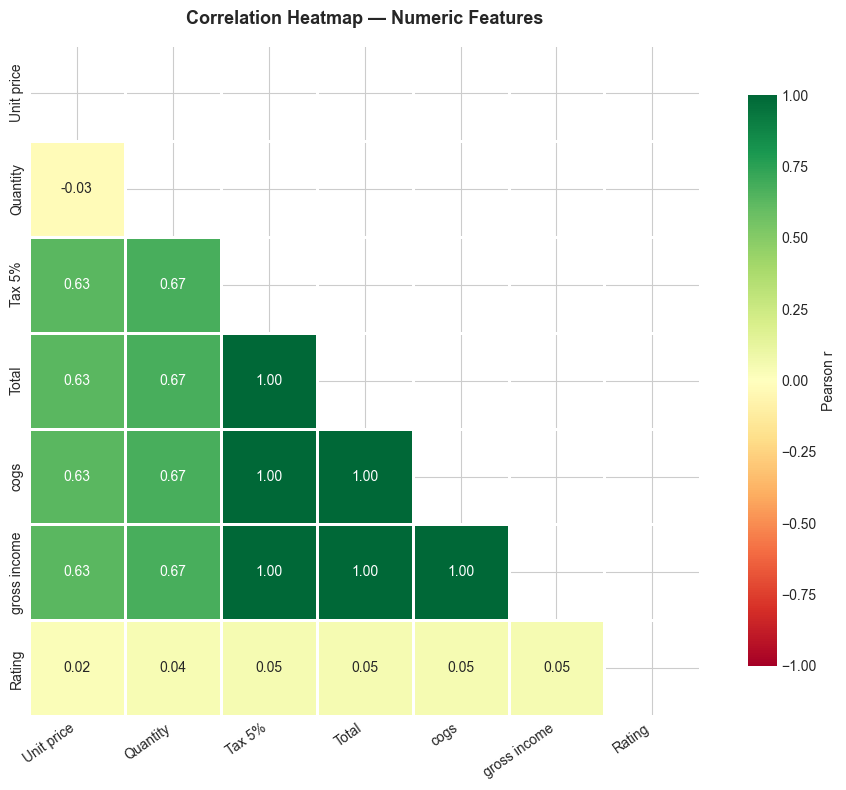


🔗 Top Correlations:
Feature 1    Feature 2    r
    Total gross income 1.00
    Total         cogs 1.00
   Tax 5%        Total 1.00
   Tax 5% gross income 1.00
   Tax 5%         cogs 1.00
     cogs gross income 1.00
 Quantity        Total 0.67
 Quantity gross income 0.67
💾 Saved: eda_07_correlation.png


In [ ]:
numeric_cols = ['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs', 'gross income', 'Rating']
corr_matrix  = df[numeric_cols].corr().round(3)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.8,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.85}
)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('eda_07_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print strongest correlations
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'r']
corr_pairs = corr_pairs[
    (corr_pairs['Feature 1'] != corr_pairs['Feature 2']) &
    (corr_pairs['Feature 1'] < corr_pairs['Feature 2'])
].sort_values('r', ascending=False)

print('\n🔗 Top Correlations:')
print(corr_pairs.head(8).to_string(index=False))
print('💾 Saved: eda_07_correlation.png')

---
## Step 9: Interactive Plotly Charts

In [16]:
# ── Interactive 1: Daily revenue trend by branch ──────────────────────────────
daily_branch = df.groupby(['Date', 'Branch'])['Total'].sum().reset_index()
daily_branch['Rolling_7'] = daily_branch.groupby('Branch')['Total'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

fig = px.line(
    daily_branch, x='Date', y='Total', color='Branch',
    title='📈 Daily Revenue by Branch (Interactive — hover, zoom, click legend)',
    color_discrete_map={'A': '#2ecc71', 'B': '#3498db', 'C': '#e74c3c'},
    labels={'Total': 'Revenue (₹)', 'Date': 'Date'}
)
fig.update_layout(
    hovermode='x unified',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font_family='Arial',
    legend_title='Branch'
)
fig.update_traces(line_width=2)
fig.show()

In [17]:
# ── Interactive 2: Sunburst — Branch → Product Line → Payment ─────────────────
fig2 = px.sunburst(
    df,
    path=['Branch', 'Product line', 'Payment'],
    values='Total',
    title='🌞 Revenue Breakdown: Branch → Product Line → Payment Method',
    color='Branch',
    color_discrete_map={'A': '#2ecc71', 'B': '#3498db', 'C': '#e74c3c'}
)
fig2.update_traces(textinfo='label+percent entry')
fig2.update_layout(height=550)
fig2.show()

In [18]:
# ── Interactive 3: Scatter — Unit Price vs Total, colored by Product Line ─────
fig3 = px.scatter(
    df,
    x='Unit price', y='Total',
    color='Product line',
    size='Quantity',
    hover_data=['Branch', 'Customer type', 'Payment', 'Rating'],
    title='💰 Unit Price vs Total Revenue (size = quantity)',
    opacity=0.6,
    labels={'Unit price': 'Unit Price (₹)', 'Total': 'Transaction Total (₹)'}
)
fig3.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig3.show()

---
## Step 10: Monthly & Seasonal Analysis

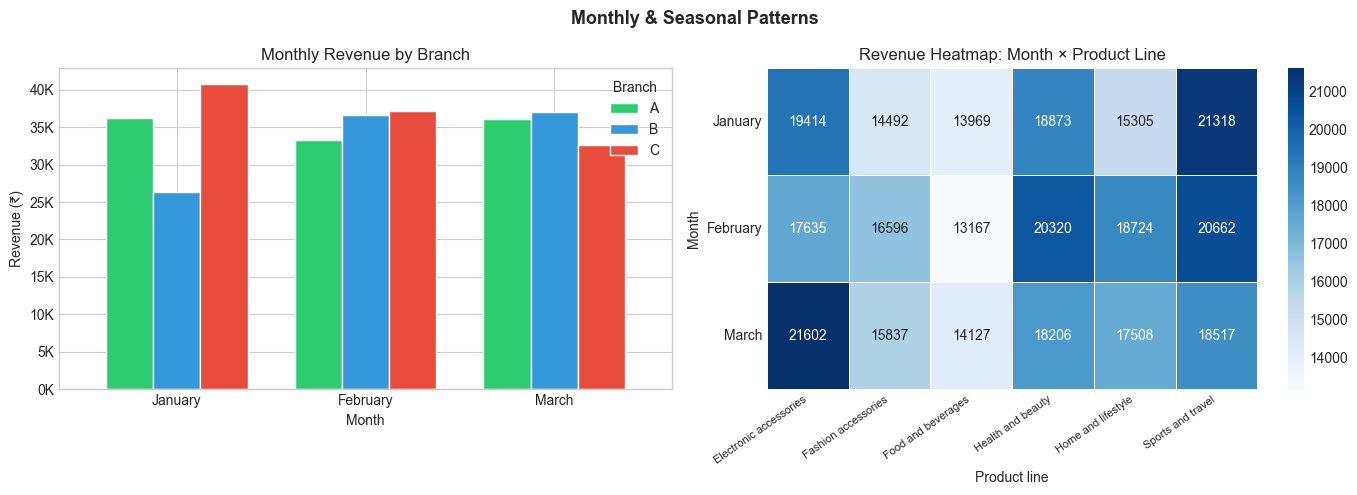

💾 Saved: eda_08_monthly.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monthly & Seasonal Patterns', fontsize=13, fontweight='bold')

# Month × Branch revenue
monthly_branch = df.groupby(['Month', 'Branch'], observed=True)['Total'].sum().unstack()
monthly_branch.plot(kind='bar', ax=axes[0],
                    color=[BRAND_COLORS['A'], BRAND_COLORS['B'], BRAND_COLORS['C']],
                    edgecolor='white', width=0.75)
axes[0].set_title('Monthly Revenue by Branch')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (₹)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend(title='Branch')

# Month × Product line revenue (heatmap style)
monthly_pl = df.pivot_table(values='Total', index='Month', columns='Product line',
                             aggfunc='sum', observed=True).round(0)
sns.heatmap(monthly_pl, annot=True, fmt='.0f', cmap='Blues', ax=axes[1],
            linewidths=0.5)
axes[1].set_title('Revenue Heatmap: Month × Product Line')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right', fontsize=8)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('eda_08_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_08_monthly.png')

---
## Step 11: Final Insight Report


In [ ]:
top_branch      = branch_summary['Total_Revenue'].idxmax()
top_branch_rev  = branch_summary['Total_Revenue'].max()
top_pl          = pl_summary['Total_Revenue'].idxmax()
top_pl_rev      = pl_summary['Total_Revenue'].max()
best_day        = df.groupby('DayOfWeek', observed=True)['Total'].sum().idxmax()
peak_hour_val   = df.groupby('Hour')['Total'].sum()
peak_hour       = peak_hour_val.idxmax()
top_payment     = df['Payment'].value_counts().idxmax()
low_pl          = pl_summary['Total_Revenue'].idxmin()
best_rated_pl   = pl_summary['Avg_Rating'].idxmax()
member_avg      = df[df['Customer type']=='Member']['Total'].mean()
normal_avg      = df[df['Customer type']=='Normal']['Total'].mean()

report = f"""
{'='*65}
       SUPERMARKET SALES — EDA INSIGHT REPORT (Q1 2019)
{'='*65}

DATASET
  Transactions : {len(df):,}
  Total Revenue: ₹{df['Total'].sum():,.0f}
  Period       : {df['Date'].min().date()} → {df['Date'].max().date()}

{'─'*65}
10 KEY BUSINESS INSIGHTS
{'─'*65}

1. BEST BRANCH
   Branch {top_branch} leads with ₹{top_branch_rev:,.0f} total revenue.
   Action: Replicate its strategies in underperforming branches.

2. TOP PRODUCT LINE
   '{top_pl}' generates the highest revenue at ₹{top_pl_rev:,.0f}.
   Action: Increase shelf space and promotions for this category.

3. UNDERPERFORMING CATEGORY
   '{low_pl}' has the lowest revenue.
   Action: Run targeted discount campaigns or review pricing.

4. BEST RATED PRODUCT
   '{best_rated_pl}' has the highest average customer rating.
   Action: Highlight in marketing — customers love it.

5. BUSIEST DAY
   {best_day} generates the highest weekly revenue.
   Action: Schedule more staff and stock replenishment on {best_day}.

6. PEAK SHOPPING HOUR
   Hour {peak_hour}:00 sees peak revenue.
   Action: Ensure all checkout counters are open and stocked at this time.

7. PREFERRED PAYMENT
   '{top_payment}' is the most popular payment method.
   Action: Ensure seamless {top_payment} processing infrastructure.

8. MEMBER vs NORMAL SPEND
   Members avg ₹{member_avg:.0f} vs Normal customers ₹{normal_avg:.0f} per transaction.
   {'Members spend more — loyalty program is effective!' if member_avg > normal_avg else 'Normal customers spend more — review member incentives.'}

9. STRONG CORRELATIONS
   Total ↔ COGS ↔ Tax: Perfect correlation (expected — derived columns).
   Unit Price → Total: Moderate positive effect.
   Rating: Mostly independent — not driven by price or quantity.

10. SEASONAL PATTERN
    Revenue is relatively stable across Jan–Mar with slight variation.
    Action: Prepare for any upcoming seasonal events (holidays, festivals).

{'='*65}
RECOMMENDED NEXT STEPS
{'─'*65}
  • Stage 3: Build a regression model to predict transaction value
  • Stage 4: Classify customer type from purchase behaviour
  • Stage 6: Cluster customers by spending patterns (RFM)

#   Letter	Full Form	Meaning
# R	Recency	   கடைசியாக எப்போது வாங்கினார்
# F	Frequency	எத்தனை முறை வாங்கினார்
# M	Monetary	   எவ்வளவு பணம் செலவிட்டார்
{'='*65}
"""

print(report)

with open('eda_insight_report.txt', 'w') as f:
    f.write(report)

print('✅ Report saved: eda_insight_report.txt')


       SUPERMARKET SALES — EDA INSIGHT REPORT (Q1 2019)

DATASET
  Transactions : 1,000
  Total Revenue: ₹316,272
  Period       : 2019-01-01 → 2019-03-29

─────────────────────────────────────────────────────────────────
10 KEY BUSINESS INSIGHTS
─────────────────────────────────────────────────────────────────

1. BEST BRANCH
   Branch C leads with ₹110,561 total revenue.
   Action: Replicate its strategies in underperforming branches.

2. TOP PRODUCT LINE
   'Sports and travel' generates the highest revenue at ₹60,496.
   Action: Increase shelf space and promotions for this category.

3. UNDERPERFORMING CATEGORY
   'Food and beverages' has the lowest revenue.
   Action: Run targeted discount campaigns or review pricing.

4. BEST RATED PRODUCT
   'Food and beverages' has the highest average customer rating.
   Action: Highlight in marketing — customers love it.

5. BUSIEST DAY
   Tuesday generates the highest weekly revenue.
   Action: Schedule more staff and stock replenishment on T


**GitHub README:**
- Embed `eda_07_correlation.png` (heatmap) and `eda_05_time_series.png` — most impressive visuals
- List all 10 insights as bullet points
- Add a badge row: `Pandas` `Seaborn` `Plotly` `Matplotlib`